## Exercise 1.4 Hotdog -- no hotdog
This is the poster hand-in project for the course. Please see the associated PDF for instructions.

In [2]:
# hei
import os
import numpy as np
import glob
import PIL.Image as Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

We always check that we are running on a GPU

In [3]:
if torch.cuda.is_available():
    print("The code will run on GPU.")
else:
    print("The code will run on CPU. Go to Edit->Notebook Settings and choose GPU as the hardware accelerator")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

The code will run on CPU. Go to Edit->Notebook Settings and choose GPU as the hardware accelerator


We provide you with a class that can load the *hotdog/not hotdog* dataset you should use from /dtu/datasets1/02516/

In [6]:
class Hotdog_NotHotdog(torch.utils.data.Dataset):
    def __init__(self, train, transform, data_path='hotdog_nothotdog'):
        'Initialization'
        self.transform = transform
        data_path = os.path.join(data_path, 'train' if train else 'test')
        image_classes = [os.path.split(d)[1] for d in glob.glob(data_path +'/*') if os.path.isdir(d)]
        image_classes.sort()
        self.name_to_label = {c: id for id, c in enumerate(image_classes)}
        self.image_paths = glob.glob(data_path + '/*/*.jpg')
        
    def __len__(self):
        'Returns the total number of samples'
        return len(self.image_paths)

    def __getitem__(self, idx):
        'Generates one sample of data'
        image_path = self.image_paths[idx]
        
        image = Image.open(image_path)
        c = os.path.split(os.path.split(image_path)[0])[1]
        y = self.name_to_label[c]
        X = self.transform(image)
        return X, y

Below is the simple way of converting the images to something that can be fed through a network.
Feel free to use something other than $128\times128$ images.

In [7]:
size = 128
mean = (0.5, 0.5, 0.5)
std = (0.5, 0.5, 0.5)

train_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])
test_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

batch_size = 64
trainset = Hotdog_NotHotdog(train=True, transform=train_transform)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0)
testset = Hotdog_NotHotdog(train=False, transform=test_transform)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0)

In [ ]:
# Held-out validation split from the TRAINING data only.
# test_loader (built from train=False) is never used here - it stays untouched
# until the single final evaluation at the end of each model's training.
from sklearn.model_selection import train_test_split

def get_labels(dataset):
    labels = []
    for image_path in dataset.image_paths:
        class_name = os.path.split(os.path.split(image_path)[0])[1]
        labels.append(dataset.name_to_label[class_name])
    return np.array(labels)

train_indices, val_indices = train_test_split(
    np.arange(len(trainset)),
    test_size=0.2,
    stratify=get_labels(trainset),
    random_state=42
)

valset = Hotdog_NotHotdog(train=True, transform=test_transform)

train_subset_loader = DataLoader(
    torch.utils.data.Subset(trainset, train_indices),
    batch_size=batch_size, shuffle=True, num_workers=0
)
val_loader = DataLoader(
    torch.utils.data.Subset(valset, val_indices),
    batch_size=batch_size, shuffle=False, num_workers=0
)

Let's look at some images from our data 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9607843].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.79607844..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8980392..0.85882354].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.3803922].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.6].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.92941177..0.8117647].
Clipping input da

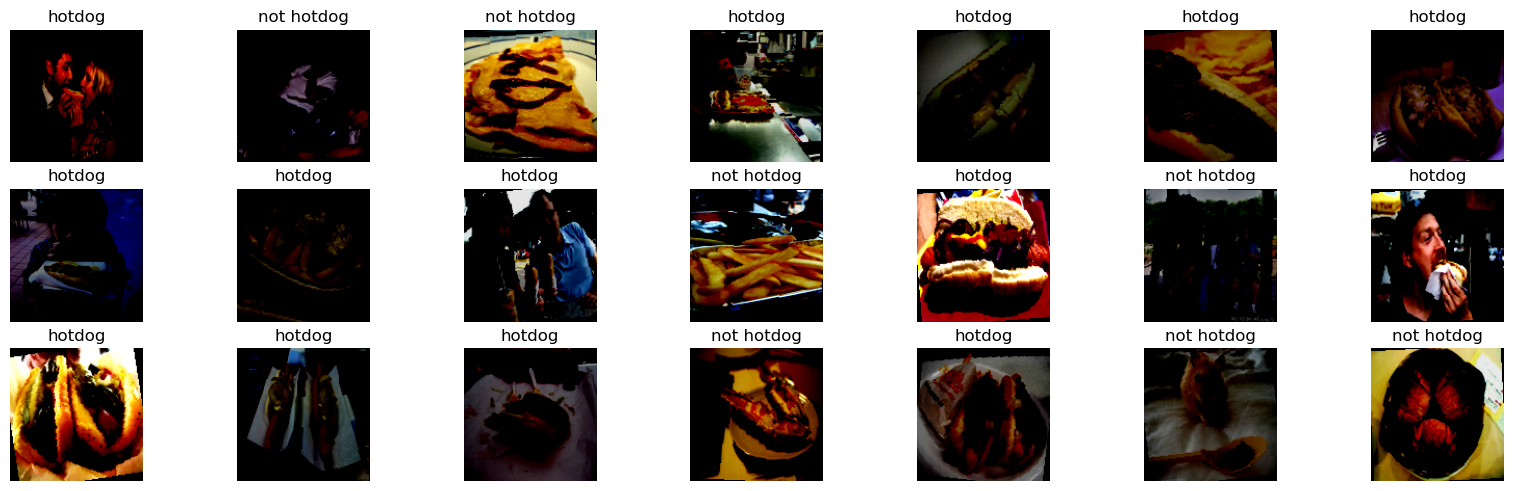

In [9]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(20,10))

for i in range(21):
    plt.subplot(5,7,i+1)
    plt.imshow(np.swapaxes(np.swapaxes(images[i].numpy(), 0, 2), 0, 1))
    plt.title(['hotdog', 'not hotdog'][labels[i].item()])
    plt.axis('off')


Now create a model and train it!


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_subset_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_accuracy = 100 * correct / total

    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_correct += (outputs.argmax(dim=1) == labels).sum().item()
            val_total += labels.size(0)

    val_accuracy = 100 * val_correct / val_total
    print(f'Epoch {epoch + 1}/{epochs} - loss: {train_loss:.4f} - train acc: {train_accuracy:.2f}% - val acc: {val_accuracy:.2f}%')

model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        test_correct += (outputs.argmax(dim=1) == labels).sum().item()
        test_total += labels.size(0)
print(f'Final test accuracy: {100 * test_correct / test_total:.2f}%')

In [10]:
class RegularizedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(64 * 4 * 4, 2)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

regularized_model = RegularizedCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    regularized_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

best_val_accuracy = 0.0
epochs_without_improvement = 0
patience = 3
epochs = 15

for epoch in range(epochs):
    regularized_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_subset_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = regularized_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_accuracy = 100 * correct / total

    regularized_model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = regularized_model(images)
            val_correct += (outputs.argmax(dim=1) == labels).sum().item()
            val_total += labels.size(0)

    val_accuracy = 100 * val_correct / val_total
    print(f'Epoch {epoch + 1}/{epochs} - loss: {train_loss:.4f} - train acc: {train_accuracy:.2f}% - val acc: {val_accuracy:.2f}%')

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        epochs_without_improvement = 0
        torch.save(regularized_model.state_dict(), 'best_regularized_cnn.pt')
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print('Early stopping')
            break

regularized_model.load_state_dict(
    torch.load('best_regularized_cnn.pt', weights_only=True)
)

regularized_model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = regularized_model(images)
        test_correct += (outputs.argmax(dim=1) == labels).sum().item()
        test_total += labels.size(0)
print(f'Final test accuracy: {100 * test_correct / test_total:.2f}%')

NameError: name 'train_subset_loader' is not defined

In [11]:
class DeeperCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25)
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128 * 4 * 4, 2)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

deeper_model = DeeperCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    deeper_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

for epoch in range(10):
    deeper_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_subset_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = deeper_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    deeper_model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = deeper_model(images)
            val_correct += (outputs.argmax(dim=1) == labels).sum().item()
            val_total += labels.size(0)

    print(
        f'Epoch {epoch + 1}/10 - '
        f'train acc: {100 * correct / total:.2f}% - '
        f'val acc: {100 * val_correct / val_total:.2f}%'
    )

deeper_model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = deeper_model(images)
        test_correct += (outputs.argmax(dim=1) == labels).sum().item()
        test_total += labels.size(0)
print(f'Final test accuracy: {100 * test_correct / test_total:.2f}%')

NameError: name 'train_subset_loader' is not defined

In [12]:
from torchvision import models

imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)
transfer_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])
transfer_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

transfer_trainset = Hotdog_NotHotdog(
    train=True,
    transform=transfer_train_transform
)
transfer_valset = Hotdog_NotHotdog(
    train=True,
    transform=transfer_test_transform
)
transfer_train_subset_loader = DataLoader(
    torch.utils.data.Subset(transfer_trainset, train_indices),
    batch_size=32,
    shuffle=True,
    num_workers=0
)
transfer_val_loader = DataLoader(
    torch.utils.data.Subset(transfer_valset, val_indices),
    batch_size=32,
    shuffle=False,
    num_workers=0
)
transfer_testset = Hotdog_NotHotdog(
    train=False,
    transform=transfer_test_transform
)
transfer_test_loader = DataLoader(
    transfer_testset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

weights = models.ResNet18_Weights.DEFAULT
transfer_model = models.resnet18(weights=weights)

for parameter in transfer_model.parameters():
    parameter.requires_grad = False

transfer_model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(transfer_model.fc.in_features, 2)
)
transfer_model = transfer_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(transfer_model.fc.parameters(), lr=0.001)

for epoch in range(5):
    transfer_model.train()
    correct = 0
    total = 0

    for images, labels in transfer_train_subset_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = transfer_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    transfer_model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in transfer_val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = transfer_model(images)
            val_correct += (outputs.argmax(dim=1) == labels).sum().item()
            val_total += labels.size(0)

    print(
        f'Epoch {epoch + 1}/5 - '
        f'train acc: {100 * correct / total:.2f}% - '
        f'val acc: {100 * val_correct / val_total:.2f}%'
    )

transfer_model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for images, labels in transfer_test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = transfer_model(images)
        test_correct += (outputs.argmax(dim=1) == labels).sum().item()
        test_total += labels.size(0)
print(f'Final test accuracy: {100 * test_correct / test_total:.2f}%')

NameError: name 'train_indices' is not defined

In [40]:
from sklearn.model_selection import StratifiedKFold

cv_trainset = Hotdog_NotHotdog(
    train=True,
    transform=transfer_train_transform
)
cv_valset = Hotdog_NotHotdog(
    train=True,
    transform=transfer_test_transform
)

cv_labels = []
for image_path in cv_trainset.image_paths:
    class_name = os.path.split(os.path.split(image_path)[0])[1]
    cv_labels.append(cv_trainset.name_to_label[class_name])

cv_labels = np.array(cv_labels)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []

for fold, (train_indices, val_indices) in enumerate(skf.split(cv_trainset.image_paths, cv_labels), start=1):
    print(f'Fold {fold}/5')

    fold_train_loader = DataLoader(
        torch.utils.data.Subset(cv_trainset, train_indices),
        batch_size=32,
        shuffle=True,
        num_workers=0
    )
    fold_val_loader = DataLoader(
        torch.utils.data.Subset(cv_valset, val_indices),
        batch_size=32,
        shuffle=False,
        num_workers=0
    )

    fold_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for parameter in fold_model.parameters():
        parameter.requires_grad = False

    fold_model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(fold_model.fc.in_features, 2)
    )
    fold_model = fold_model.to(device)
    fold_optimizer = torch.optim.Adam(fold_model.fc.parameters(), lr=0.001)
    fold_criterion = nn.CrossEntropyLoss()

    for epoch in range(5):
        fold_model.eval()
        fold_model.fc.train()

        for images, labels in fold_train_loader:
            images, labels = images.to(device), labels.to(device)
            fold_optimizer.zero_grad()
            outputs = fold_model(images)
            loss = fold_criterion(outputs, labels)
            loss.backward()
            fold_optimizer.step()

    fold_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in fold_val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = fold_model(images)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    fold_accuracy = 100 * correct / total
    fold_accuracies.append(fold_accuracy)
    print(f'Validation accuracy: {fold_accuracy:.2f}%')

print(f'5-fold mean accuracy: {np.mean(fold_accuracies):.2f}%')
print(f'5-fold standard deviation: {np.std(fold_accuracies):.2f}%')

Fold 1/5
Validation accuracy: 93.90%
Fold 2/5
Validation accuracy: 92.44%
Fold 3/5
Validation accuracy: 92.18%
Fold 4/5
Validation accuracy: 94.87%
Fold 5/5
Validation accuracy: 92.18%
5-fold mean accuracy: 93.11%
5-fold standard deviation: 1.09%
